# Lab 25: Linear Regression

**Helpful Resource:**

- [Python Reference](http://data8.org/sp24/reference/): Cheat sheet of helpful array & table methods!

**Recommended Readings**:

* [Correlation](https://inferentialthinking.com/chapters/15/1/Correlation.html)
* [The Regression Line](https://www.inferentialthinking.com/chapters/15/2/Regression_Line.html)
* [Method of Least Squares](https://www.inferentialthinking.com/chapters/15/3/Method_of_Least_Squares.html)
* [Least Squares Regression](https://www.inferentialthinking.com/chapters/15/4/Least_Squares_Regression.html)

In [1]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc
!pip install datascience

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [2]:
# Connect Google Drive to Colab so you can access your files
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/')

Mounted at /content/drive


In [3]:
# Run this cell to set up the notebook, but please don't change it.

import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)
from datetime import datetime

## 1. Linear Regression Setup

When performing linear regression, we need to compute several important quantities which will be used throughout our analysis. **Unless otherwise specified when asked to make a prediction please assume we are predicting y from x throughout this assignment.** To help with our later analysis, we will begin by writing some of these functions and understanding what they can do for us.

**Question 1.1.** Define a function `standard_units` that converts a given array to standard units. **(3 points)**

*Hint:* You may find the `np.mean` and `np.std` functions helpful.


In [4]:
def standard_units(data):
    return (data - np.mean(data)) / np.std(data)

**Question 1.2.** Which of the following are true about standard units? Assume we have converted an array of data into standard units using the function above. **(5 points)**

1. The unit of all our data when converted into standard units is the same as the unit of the original data.
2. The sum of all our data when converted into standard units is 0.
3. The standard deviation of all our data when converted into standard units is 1.
4. Adding a constant, C, to our original data has no impact on the resultant data when converted to standard units.
5. Multiplying our original data by a positive constant, C (>0), has no impact on the resultant data when converted to standard units.

Assign `standard_array` to an array of your selections, in increasing numerical order. For example, if you wanted to select options 1, 3, and 5,
you would assign `standard_array` to `make_array(1, 3, 5)`.


In [5]:
standard_array = make_array(2, 3, 4, 5)

**Question 1.3.** Define a function `correlation` that computes the correlation between 2 arrays of data in original units. **(3 points)**

*Hint:* Feel free to use functions you have defined previously.


In [6]:
def correlation(x, y):
    x_su = standard_units(x)
    y_su = standard_units(y)
    return np.mean(x_su * y_su)

**Question 1.4.** Which of the following are true about the correlation coefficient $r$? **(5 points)**

1. The correlation coefficient measures the strength of a linear relationship.
2. When looking at the existing data, a correlation coefficient of 1.0 means an increase in one variable always means an increase in the other variable.
3. The correlation coefficient is the slope of the regression line in standard units.
4. The correlation coefficient stays the same if we swap our x-axis and y-axis.
5. If we add a constant, C, to our original data, our correlation coefficient will increase by the same C.

Assign `r_array` to an array of your selections, in increasing numerical order. For example, if you wanted to select options 1, 3, and 5,
you would assign `r_array` to `make_array(1, 3, 5)`.


In [7]:
r_array = make_array(1, 2, 3, 4)

**Question 1.5.** Define a function `slope` that computes the slope of our line of best fit (to predict y given x), given two arrays of data in original units. Assume we want to create a line of best fit in original units. **(3 points)**

*Hint:* Feel free to use functions you have defined previously.


In [8]:
def slope(x, y):
    r = correlation(x, y)
    return r * (np.std(y) / np.std(x))

**Question 1.6.** Which of the following are true about the slope of our line of best fit? Assume `x` refers to the value of one variable that we use to predict the value of `y`. **(5 points)**

1. In original units, the slope has the unit: unit of x / unit of y.
2. In standard units, the slope is unitless.
3. In original units, the slope is unchanged by swapping x and y.
4. In standard units, a slope of 1 means our data is perfectly linearly correlated.
5. In original units and standard units, the slope always has the same positive or negative sign.

Assign `slope_array` to an array of your selections, in increasing numerical order. For example, if you wanted to select options 1, 3, and 5,
you would assign `slope_array` to `make_array(1, 3, 5)`.


In [9]:
slope_array = make_array(2, 4, 5)

**Question 1.7.** Define a function `intercept` that computes the intercept of our line of best fit (to predict y given x), given 2 arrays of data in original units. Assume we want to create a line of best fit in original units. **(3 points)**

*Hint:* Feel free to use functions you have defined previously.


In [10]:
def intercept(x, y):
    return np.mean(y) - slope(x, y) * np.mean(x)

**Question 1.8.** Which of the following are true about the intercept of our line of best fit? Assume `x` refers to the value of one variable that we use to predict the value of `y`. **(5 points)**

1. In original units, the intercept has the same unit as the y values.
2. In original units, the intercept has the same unit as the x values.
3. In original units, the slope and intercept have the same unit.
4. In standard units, the intercept for the regression line is 0.
5. In original units and standard units, the intercept always has the same numerical value.

Assign `intercept_array` to an array of your selections, in increasing numerical order. For example, if you wanted to select options 1, 3, and 5,
you would assign `intercept_array` to `make_array(1, 3, 5)`.


In [11]:
intercept_array = make_array(1, 4)

**Question 1.9.** Define a function `predict` that takes in a table and 2 column names, and returns an array of predictions. The predictions should be created using a fitted **regression line**. We are predicting `"col2"` from `"col1"`, both in original units. **(5 points)**

*Hint 1:* Feel free to use functions you have defined previously.

*Hint 2:* Re-reading [15.2](https://inferentialthinking.com/chapters/15/2/Regression_Line.html#the-regression-line) might be helpful here.

Note: The public tests are quite comprehensive for this question, so passing them means that your function most likely works correctly.


In [12]:
def predict(tbl, col1, col2):
    x = tbl.column(col1)
    y = tbl.column(col2)
    a = slope(x, y)
    b = intercept(x, y)
    return a * x + b

## 2. FIFA Predictions

The following data was scraped from [sofifa.com](https://sofifa.com/), a website dedicated to collecting information from FIFA video games. The dataset consists of all players in FIFA 22 and their corresponding attributes. We have truncated the dataset to a limited number of rows (100) to ease with our visualizations and analysis. Since we’re learning about linear regression, we will look specifically for a linear association between various player attributes. **To help with understanding where the line of best fit generated in linear regression comes from please do not use the `.fit_line` argument in `.scatter` at any point on question 2 unless the code was provided for you.**

Feel free to read more about the video game on [Wikipedia](https://en.wikipedia.org/wiki/FIFA_22).

In [13]:
# Run this cell to load the data
fifa = Table.read_table('./DS/fifa22.csv')

fifa = fifa.take(np.arange(100))
# Select a subset of columns to analyze (there are 110 columns in the original dataset)
fifa = fifa.select("short_name", "overall", "value_eur", "wage_eur", "age", "pace", "shooting", "passing", "attacking_finishing")
fifa.show(5)

/usr/local/lib/python3.12/dist-packages/datascience/tables.py:163: DtypeWarning: Columns (25,108) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pandas.read_csv(filepath_or_buffer, *args, **vargs)


short_name,overall,value_eur,wage_eur,age,pace,shooting,passing,attacking_finishing
L. Messi,93,7.8e+07,320000,34,85,92,91,95
R. Lewandowski,92,1.195e+08,270000,32,78,92,79,95
Cristiano Ronaldo,91,4.5e+07,270000,36,87,94,80,95
Neymar Jr,91,1.29e+08,270000,29,91,83,86,83
K. De Bruyne,91,1.255e+08,350000,30,76,86,93,82


<!-- BEGIN QUESTION -->

**Question 2.1.** Before jumping into any statistical techniques, it’s important to see what the data looks like, because data visualizations allow us to uncover patterns in our data that would have otherwise been much more difficult to see. **(3 points)**

Create a scatter plot with age on the x-axis (“age”), and the player’s value in Euros (“value_eur”) on the y-axis.


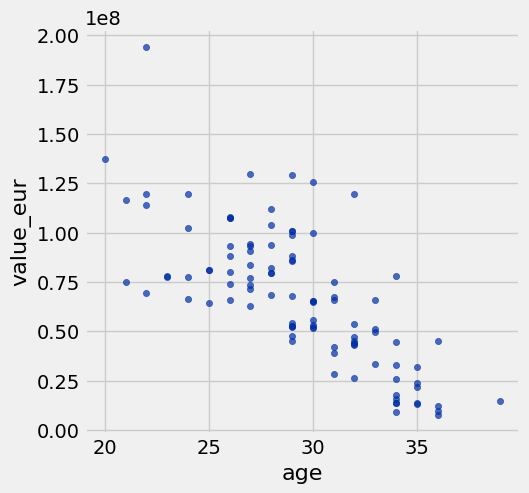

In [14]:
fifa.scatter('age', 'value_eur')

<!-- END QUESTION -->

**Question 2.2.** Does the correlation coefficient `r` for the data in our scatter plot in 2.1 look closest to 0, 0.75, or -0.75? **(3 points)**

Assign `r_guess` to one of 0, 0.75, or -0.75.


In [15]:
r_guess = 0.75

<!-- BEGIN QUESTION -->

**Question 2.3.** Create a scatter plot with player age ("age") along the x-axis and both real player value ("value_eur") and predicted player value along the y-axis. The predictions should be created using a fitted **regression line**. The color of the dots for the real player values should be different from the color for the predicted player values. **(8 points)**

*Hint 1:* Feel free to use functions you have defined previously.

*Hint 2:* [15.2](https://inferentialthinking.com/chapters/15/2/Regression_Line.html#) and [7.3](https://inferentialthinking.com/chapters/07/3/Overlaid_Graphs.html#overlaid-scatter-plots) has examples of creating such scatter plots.


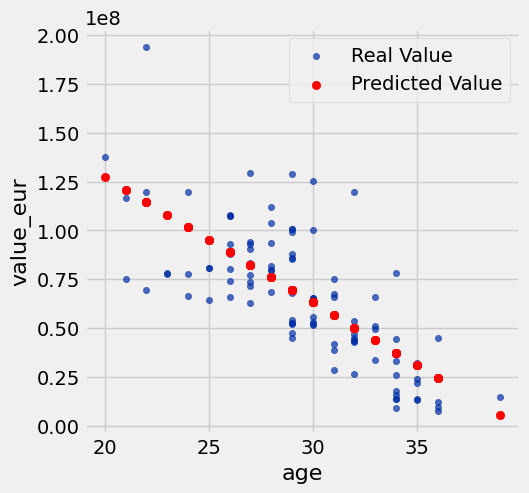

In [16]:
predictions = predict(fifa, 'age', 'value_eur')
fifa_with_predictions = fifa.with_columns(
    'Predicted Value', predictions
)
fifa_with_predictions.scatter('age', 'value_eur', label='Real Value')
plt.scatter(fifa_with_predictions.column('age'), fifa_with_predictions.column('Predicted Value'), color='red', label='Predicted Value')
plt.legend()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 2.4.** Looking at the scatter plot you produced above, is linear regression a good model to use? If so, what features or characteristics make this model reasonable? If not, what features or characteristics make it unreasonable? **(5 points)**


Linear regression may not be a good model for this data. Looking at the scatterplot, player value initially increases with age, peaks around age 25-30, and then declines. This is closer to a U-shaped or parabolic relationship. Because linear regression assumes a straight line, it fails to capture the curvilinear pattern in this data and can lead to significant discrepancies between predicted and actual values. Therefore, it may tend to underestimate or overestimate the actual value for both young and older players.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 2.5.** In 2.3, we created a scatter plot **in original units**. Now, create a scatter plot with player age **in standard units** along the x-axis and both real and predicted player value **in standard units** along the y-axis. The color of the dots of the real and predicted values should be different. **(8 points)**

*Hint:* Feel free to use functions you have defined previously.


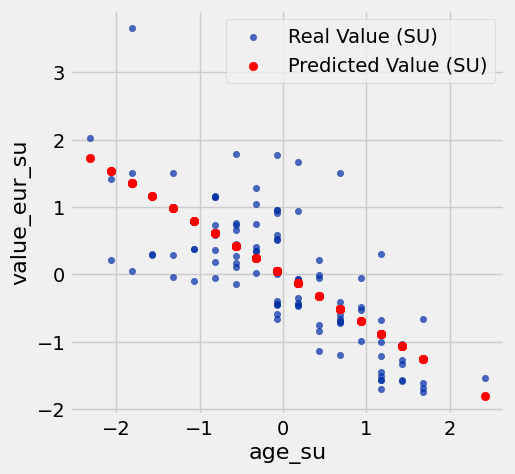

In [17]:
age_su = standard_units(fifa.column('age'))
value_eur_su = standard_units(fifa.column('value_eur'))

fifa_su_table = Table().with_columns(
    'age_su', age_su,
    'value_eur_su', value_eur_su
)

predictions_su = predict(fifa_su_table, 'age_su', 'value_eur_su')

fifa_with_predictions_su = fifa_su_table.with_columns(
    'Predicted Value (SU)', predictions_su
)

fifa_with_predictions_su.scatter('age_su', 'value_eur_su', label='Real Value (SU)')
plt.scatter(fifa_with_predictions_su.column('age_su'), fifa_with_predictions_su.column('Predicted Value (SU)'), color='red', label='Predicted Value (SU)')
plt.legend()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 2.6.** Compare your plots in 2.3 and 2.5. What similarities do they share? What differences do they have? **(5 points)**


Similarities: The two graphs share similar patterns in terms of shape and relative distribution of points. That is, the trend of increasing values ​​with age, peaking at a certain point, and then decreasing is observed in both graphs. This is because standardization transformation only adjusts the scale without changing the underlying relationship between the data.

Differences: The key difference is the scale and units of the axes. The graph in Question 2.3 displays the data in its original units (years for age and euros for value), while the graph in Question 2.5 displays the data in standard units (mean 0, standard deviation 1). This causes the graph in Question 2.5 to be centered around 0 on both the x- and y-axes, and the absolute values ​​of the points are smaller than those in the graph in Question 2.3. However, the relative positions and patterns of the points remain the same.

<!-- END QUESTION -->

**Question 2.7.** Define a function `rmse` that takes in two arguments: a slope and an intercept for a potential regression line. The function should return the root mean squared error between the values predicted by a regression line with the given slope and intercept and the actual outcomes. **(6 points)**

Assume we are still predicting “value_eur” from “age” in original units from the `fifa` table.


In [18]:
def rmse(slope, intercept):
    x = fifa.column('age')
    y = fifa.column('value_eur')
    predictions = slope * x + intercept
    errors = y - predictions
    return np.sqrt(np.mean(errors ** 2))

<!-- BEGIN QUESTION -->

**Question 2.8.** Use the `rmse` function you defined along with `minimize` to find the least-squares regression parameters predicting player value from player age. Here's an [example](https://inferentialthinking.com/chapters/15/3/Method_of_Least_Squares.html#numerical-optimization) of using the `minimize` function from the textbook. **(10 points)**

Then set `lsq_slope` and `lsq_intercept` to be the least-squares regression line slope and intercept, respectively.

Finally, create a scatter plot like you did in 2.3 with player age ("age") along the x-axis and both real player value ("value_eur") and predicted player value along the y-axis. **Be sure to use your least-squares regression line to compute the predicted values.** The color of the dots for the real player values should be different from the color for the predicted player values.

> **Note:** Your solution should not make any calls to the slope or intercept functions defined earlier.

*Hint:* Your call to `minimize` will return an array of argument values that minimize the return value of the function passed to `minimize`.

Slope: -6.41462e+06 | Intercept: 2.55525e+08


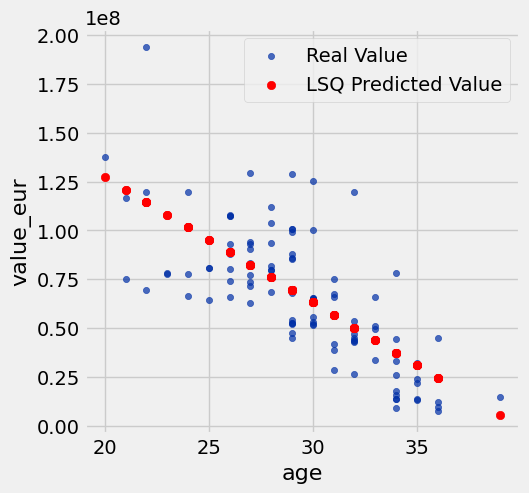

In [19]:
from datascience.predicates import are

minimized_parameters = minimize(rmse)
lsq_slope = minimized_parameters.item(0)
lsq_intercept = minimized_parameters.item(1)

# This just prints your slope and intercept
print("Slope: {:g} | Intercept: {:g}".format(lsq_slope, lsq_intercept))

# Calculate predictions using the least-squares line
x_values = fifa.column('age')
lsq_predictions = lsq_slope * x_values + lsq_intercept

fifa_with_lsq_predictions = fifa.with_columns(
    'Predicted Value (LSQ)', lsq_predictions
)

fifa_with_lsq_predictions.scatter('age', 'value_eur', label='Real Value')
plt.scatter(fifa_with_lsq_predictions.column('age'), fifa_with_lsq_predictions.column('Predicted Value (LSQ)'), color='red', label='LSQ Predicted Value')
plt.legend()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 2.9.** The resulting line you found in 2.8 should appear very similar to the line you found in 2.3. Why were we able to minimize RMSE to find nearly the same slope and intercept from the previous formulas? **(5 points)**

*Hint:* Re-reading [15.3](https://inferentialthinking.com/chapters/15/3/Method_of_Least_Squares.html#the-least-squares-line) might be helpful here.


Minimizing the Root Mean Squared Error (RMSE) is the core principle of the Least Squares Method. Least Squares finds a regression line by minimizing the sum of the squares of the vertical distances (residuals) between the observed data and the regression line. Since RMSE is the square root of the average of these squared residuals, minimizing RMSE is mathematically equivalent to minimizing the sum (or mean) of the squared residuals.

Therefore, the slope and intercept functions we defined in Question 2.3 directly compute the solution to this Least Squares Method. In other words, they are mathematical formulas for the slope and intercept that minimize the sum of squared residuals using the correlation coefficient, standard deviation, and mean. In contrast, Question 2.8 uses the minimize function to find the slope and intercept that "numerically" minimize the RMSE function. Since both methods share the same goal of "minimizing the sum of squared residuals," theoretically, they should find the same optimal line (the least squares regression line). Although there may be very slight differences due to some floating point errors in the numerical optimization process, the results are essentially the same.

<!-- END QUESTION -->

**Question 2.10** For which of the following error functions would we have resulted in the same slope and intercept values in 2.8 instead of using RMSE? Assume `error` is assigned to the actual values minus the predicted values. **(5 points)**

1. `np.sum(error) ** 0.5`
2. `np.sum(error ** 2)`
3. `np.mean(error) ** 0.5`
4. `np.mean(error ** 2)`

Assign `error_array` to an array of your selections, in increasing numerical order. For example, if you wanted to select options 1, 3, and 5,
you would assign `error_array` to `make_array(1, 3, 5)`.

Hint: What was the purpose of RMSE? Are there any alternatives, and if so, does minimizing them them yield the same results as minimizing the RMSE?

In [20]:
error_array = make_array(2, 4)

In [21]:
# goalies don't have shooting in our dataset so we removed them before looking at the pace stat
no_goalies = fifa.where("shooting", are.above(0))
no_goalies

short_name,overall,value_eur,wage_eur,age,pace,shooting,passing,attacking_finishing
L. Messi,93,7.8e+07,320000,34,85,92,91,95
R. Lewandowski,92,1.195e+08,270000,32,78,92,79,95
Cristiano Ronaldo,91,4.5e+07,270000,36,87,94,80,95
Neymar Jr,91,1.29e+08,270000,29,91,83,86,83
K. De Bruyne,91,1.255e+08,350000,30,76,86,93,82
K. Mbappé,91,1.94e+08,230000,22,97,88,80,93
H. Kane,90,1.295e+08,240000,27,70,91,83,94
N. Kanté,90,1e+08,230000,30,78,66,75,65
K. Benzema,89,6.6e+07,350000,33,76,86,81,90
H. Son,89,1.04e+08,220000,28,88,87,82,88


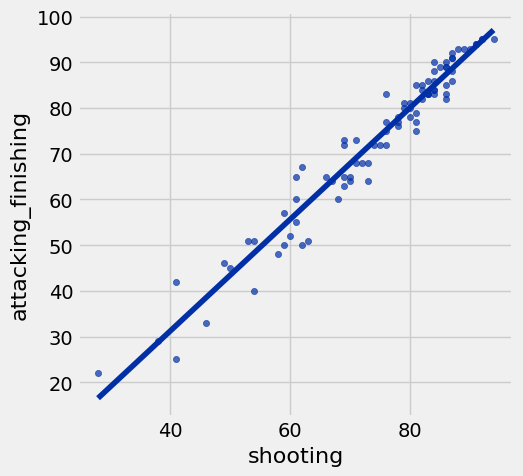

In [22]:
# Run this cell to generate a scatter plot for the next part.
no_goalies.scatter('shooting', 'attacking_finishing', fit_line=True)

**Question 2.11.** Above is a scatter plot showing the relationship between a player’s shooting ability (“shooting”) and their scoring ability (“attacking_finishing”).

There is clearly a strong positive correlation between the 2 variables, and we’d like to predict a player’s scoring ability from their shooting ability. Which of the following are true, assuming linear regression is a reasonable model? **(5 points)**

*Hint:* Re-reading [15.2](https://inferentialthinking.com/chapters/15/2/Regression_Line.html#) might be helpful here.

1. For a majority of players with a `shooting` attribute above 80 our model predicts they have a better scoring ability than shooting ability.
2. A randomly selected player's predicted scoring ability in standard units will always be less than their shooting ability in standard units.
3. If we select a player who’s shooting ability is 1.0 in standard units, their scoring ability, on average, will be less than 1.0 in standard units.
4. Goalies have attacking_finishing scores in our dataset but do not have shooting scores. We can still use our model to predict their attacking_finishing scores.

Assign `scoring_array` to an array of your selections, in increasing numerical order. For example, if you wanted to select options 1, 3, and 5,
you would assign `scoring_array` to `make_array(1, 3, 5)`.


In [23]:
scoring_array = make_array(3)

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a pdf file for you to submit. **Please save before exporting!**

In [ ]:
# should change the directory and file name matching to yours
!jupyter nbconvert './DS/lab25(SSU).ipynb' --to pdf

[NbConvertApp] Converting notebook ./DS/lab25(SSU).ipynb to pdf
[NbConvertApp] Support files will be in lab25(SSU)_files/
[NbConvertApp] Making directory ./lab25(SSU)_files
[NbConvertApp] Writing 91577 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
